### Imports

In [2]:
!pip install matplotlib

Defaulting to user installation because normal site-packages is not writeable
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.3 MB 9.6 MB/s eta 0:00:01
   ------------- -------------------------- 3.1/9.3 MB 8.4 MB/s eta 0:00:01
   --------------------- ------------------ 5.0/9.3 MB 8.6 MB/s eta 0:00:01
   ---------------------------- ----------- 6.6/9.3 MB 8.4 MB/s eta 0:00:01
   ---------------------------------- ----- 8.1/9.3 MB 8.3 MB/s eta 0:00:01
   ---------------------------------------- 9.3/9.3 MB 8.0 MB/s  0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.5 MB ? eta -:--:--
   ------------------------- -------------- 1.6/2.5 MB 7.5 MB/s eta 0:00:01
   ---------------------------------------- 2.5/2.5 MB 7.9 MB/s  0:00:00

   ---------------------------------------- 0/6 [pyparsing]
   -


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: C:\Users\Shivanshu Sirohi\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader

print("Pytorch version :", torch.__version__)
print("CUDA available :", torch.cuda.is_available())

Pytorch version : 2.14.0+cpu
CUDA available : False


### Define Dataset Paths

In [10]:
project_dir = Path(
    r"C:\Users\Shivanshu Sirohi\Documents\Object_detection_from_scratch"
)

data_dir = project_dir / "data"

data_dir.mkdir(
    parents=True,
    exist_ok=True
)

voc_dir = data_dir / "VOCdevkit" / "VOC2007"

print("Project directory :", project_dir)
print("Data directory    :", data_dir)
print("VOC directory     :", voc_dir)

print("Project exists :", project_dir.exists())
print("Data exists    :", data_dir.exists())
print("VOC exists     :", voc_dir.exists())

Project directory : C:\Users\Shivanshu Sirohi\Documents\Object_detection_from_scratch
Data directory    : C:\Users\Shivanshu Sirohi\Documents\Object_detection_from_scratch\data
VOC directory     : C:\Users\Shivanshu Sirohi\Documents\Object_detection_from_scratch\data\VOCdevkit\VOC2007
Project exists : True
Data exists    : True
VOC exists     : False


### Download Pascal VOC 2007

In [14]:
from urllib.request import urlretrieve                   # downloads a file from a URL and saves it locally

voc_url = "http://host.robots.ox.ac.uk/pascal/VOC/voc2007/VOCtrainval_06-Nov-2007.tar"
archive_path = data_dir / "VOCtrainval_06-Nov-2007.tar"

if not archive_path.exists():
    print("Downloading Pascal VOC 2007.......")
    urlretrieve(voc_url, archive_path)
    print("Download complete")
else:
    print("Archive already exists")

print("Archive path :", archive_path)
print("Archive exists:", archive_path.exists())

Download complete
Archive path : C:\Users\Shivanshu Sirohi\Documents\Object_detection_from_scratch\data\VOCtrainval_06-Nov-2007.tar
Archive exists: True


### Extract

In [ ]:
import tarfile                                         # handles archive .tar files

if not voc_dir.exists():
    print("Extracting Pascal VOC 2007...")

    with tarfile.open(archive_path, "r") as tar:       # opens the archive for reading. 'r' means read mode
        tar.extractall(path=data_dir)                  # take everything inside our archive and extract into our data directory

    print("Extraction complete")
else:
    print("Pascal VOC 2007 already extracted")

print("VOC directort exists:", voc_dir.exists())

Extracting Pascal VOC 2007...


C:\Users\Shivanshu Sirohi\AppData\Local\Temp\ipykernel_30264\918263326.py:7: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=data_dir)


Extraction complete
VOC directort exists: True


### Inspect

In [ ]:
for item in voc_dir.iterdir():         # give me items inside this directory one by one
    print(item.name)

Annotations
ImageSets
JPEGImages
SegmentationClass
SegmentationObject


In [19]:
image_dir = voc_dir / "JPEGImages"
annotation_dir = voc_dir / "Annotations"
image_paths = list(image_dir.glob("*.jpg"))                     # find every file inside the image directory that ends with '.jpg'
annotation_paths = list(annotation_dir.glob("*.xml"))
print("Number of images      :", len(image_paths))
print("Number of annotations :", len(annotation_paths))

Number of images      : 5011
Number of annotations : 5011


In [ ]:
## Open one image
image_path = image_paths[0]
image_id = image_path.stem                               # image.name gives 00005.jpg while stem gives only 00005
annotation_path = annotation_dir / f"{image_id}.xml"     # annotations of the first image only
image = Image.open(image_path)          # open an image using the PIL-image library
print("Image path :", image_path)
print("image type :", type(image))
print("Image mode :", image.mode)
print("Image size :", image.size)       # PIL represents the image size as (W,H)
                                        # coordinates of the bounding boxes are defined relative to this coordinate system

Image path : C:\Users\Shivanshu Sirohi\Documents\Object_detection_from_scratch\data\VOCdevkit\VOC2007\JPEGImages\000005.jpg
image type : <class 'PIL.JpegImagePlugin.JpegImageFile'>
Image mode : RGB
Image size : (500, 375)


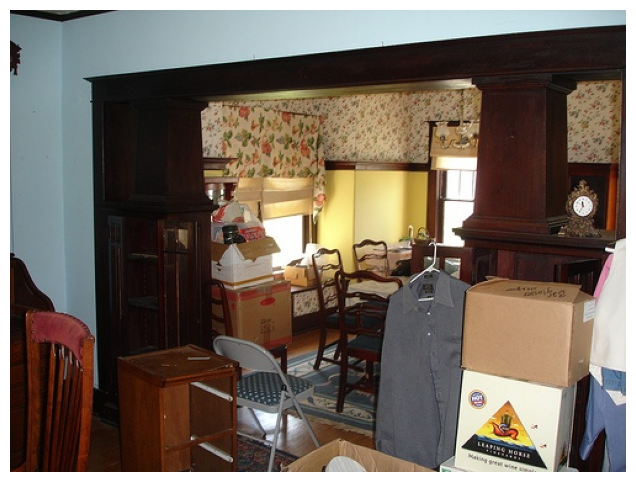

In [29]:
## Display the image
plt.figure(figsize=(8,6))
plt.imshow(image)                      # tells matplotlib what image to show
plt.axis('off')
plt.show()                             # tells matplotlib to actually render the current figure

In [30]:
image_array = np.array(image)
print("Array type  :", type(image_array))
print("Array shape :", image_array.shape)
print("Data type   :", image_array.dtype)

print("Minimum pixel value :", image_array.min())
print("Maximum pixel value :", image_array.max())

Array type  : <class 'numpy.ndarray'>
Array shape : (375, 500, 3)
Data type   : uint8
Minimum pixel value : 0
Maximum pixel value : 255


In [31]:
## reading the raw annotation, looking at what Pascal VOC stores

with open(annotation_path, 'r') as file:
    annotation_text = file.read()
print(annotation_text)

<annotation>
	<folder>VOC2007</folder>
	<filename>000005.jpg</filename>
	<source>
		<database>The VOC2007 Database</database>
		<annotation>PASCAL VOC2007</annotation>
		<image>flickr</image>
		<flickrid>325991873</flickrid>
	</source>
	<owner>
		<flickrid>archintent louisville</flickrid>
		<name>?</name>
	</owner>
	<size>
		<width>500</width>
		<height>375</height>
		<depth>3</depth>
	</size>
	<segmented>0</segmented>
	<object>
		<name>chair</name>
		<pose>Rear</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>263</xmin>
			<ymin>211</ymin>
			<xmax>324</xmax>
			<ymax>339</ymax>
		</bndbox>
	</object>
	<object>
		<name>chair</name>
		<pose>Unspecified</pose>
		<truncated>0</truncated>
		<difficult>0</difficult>
		<bndbox>
			<xmin>165</xmin>
			<ymin>264</ymin>
			<xmax>253</xmax>
			<ymax>372</ymax>
		</bndbox>
	</object>
	<object>
		<name>chair</name>
		<pose>Unspecified</pose>
		<truncated>1</truncated>
		<difficult>1</difficult>
		<bndbox>
			<xmin>

In [ ]:
## Parse XML
import xml.etree.ElementTree as ET          # ELementTree is Pythons built-in library for working with XML
                                            # XML is heirarchichal, so its useful to think of it as a tree

tree = ET.parse(annotation_path)            # reads the XML file we defined above
                                            # converts its structure into an ElementTree Python Object

root = tree.getroot()                             # top level/root element of XML document
print("Root tag :", root.tag)                     # should return 'annotation' 
print("Filename :", root.find("filename").text)   # will return the filename 000005.jpg

size = root.find('size')                    # the size itself contains three child elements - width, height, depth

width = int(size.find("width").text)        # retrievs the text inside <width>500</width> which is initially string
height = int(size.find("height").text)
depth = int(size.find("depth").text)

print("Width  :", width)
print("Height :", height)
print("Depth  :", depth)

Root tag : annotation
Filename : 000005.jpg
Width  : 500
Height : 375
Depth  : 3


In [34]:
## Extract objects and bounding boxes
objects = []

for obj in root.findall('object'):                  # we have multiple branches that starts with <object> and ends with </object>
                                                    # findall returns all matching objects

    class_name = obj.find('name').text              # <name>chair</name>
                                                    # returns the first matching object

    bbox = obj.find('bndbox')                       # looks for <bndbox>
    xmin = int(bbox.find('xmin').text)              # extract text and convert to int eg - <xmin>277</xmin>
    ymin = int(bbox.find('ymin').text)
    xmax = int(bbox.find('xmax').text)
    ymax = int(bbox.find('ymax').text)

    objects.append({
        "class": class_name,
        "bbox" : [xmin, ymin, xmax, ymax]
    })

print("Number of objects:", len(objects))

for obj in objects:
    print(obj)

Number of objects: 5
{'class': 'chair', 'bbox': [263, 211, 324, 339]}
{'class': 'chair', 'bbox': [165, 264, 253, 372]}
{'class': 'chair', 'bbox': [5, 244, 67, 374]}
{'class': 'chair', 'bbox': [241, 194, 295, 299]}
{'class': 'chair', 'bbox': [277, 186, 312, 220]}


### Draw ground-truth Bounding Boxes

In [35]:
# the bounding box format is (x_min, y_min, x_max, y_max)

In [40]:
xmin, ymin, xmax, ymax = objects[0]['bbox']

box_width = xmax - xmin
box_height = ymax - ymin

center_x = xmin + box_width / 2
center_y = ymin + box_height / 2

xyxy = [xmin, ymin, xmax, ymax]

xywh = [xmin, ymin, box_width, box_height]

cxcywh = [center_x, center_y, box_width, box_height]

print("XYXY   :", xyxy)
print("XYWH   :", xywh)
print("CXCYWH :", cxcywh)                     # the three formats describe exactly the rectangle

XYXY   : [263, 211, 324, 339]
XYWH   : [263, 211, 61, 128]
CXCYWH : [293.5, 275.0, 61, 128]


In [41]:
## so our first chair occupies X : (263 to 324) and Y : (211 to 339)
## giving widht 61 and height 128, center (293.5, 275)

In [42]:
## Normalized bounding boxes
normalized_cx = center_x / width                # width and height are processed above from the XML tree map
normalized_cy = center_y / height

normalized_width = box_width / width
normalized_height = box_height / height

normalized_box = [
    normalized_cx,
    normalized_cy,
    normalized_width,
    normalized_height
]

print("Original CXCYWH   :", cxcywh)
print("Normalized CXCYWH :", normalized_box)

Original CXCYWH   : [293.5, 275.0, 61, 128]
Normalized CXCYWH : [0.587, 0.7333333333333333, 0.122, 0.3413333333333333]


In [43]:
## ^^ the important idea is we have changed the pixel space to relative pixel space

In [44]:
## convert back just to see normalization hasn't lost any info
norm_cx, norm_cy, norm_w, norm_h = normalized_box

recovered_cx = norm_cx * width
recovered_cy = norm_cy * height

recovered_width = norm_w * width
recovered_height = norm_h * height

recovered_xmin = recovered_cx - recovered_width / 2
recovered_ymin = recovered_cy - recovered_height / 2

recovered_xmax = recovered_cx + recovered_width / 2
recovered_ymax = recovered_cy + recovered_height / 2

recovered_box = [
    recovered_xmin,
    recovered_ymin,
    recovered_xmax,
    recovered_ymax
]

print("Original XYXY  :", xyxy)
print("Recovered XYXY :", recovered_box)

Original XYXY  : [263, 211, 324, 339]
Recovered XYXY : [263.0, 211.0, 324.0, 339.0]


# Intersection Over Union (IoU)

In [46]:
# Suppose ground truth is : A = [263,211,324,339]
# and our model predicts :  B = [280, 230, 340, 350]
# IoU = Area of Intersection / Area of Union ... this is the numerical way to answer how well is the overlap

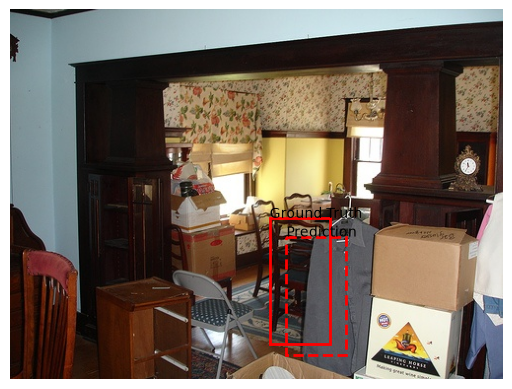

In [49]:
ground_truth_box = [263, 211, 324, 339]
predicted_box = [280, 230, 340, 350]

fig, ax = plt.subplots()

ax.imshow(image)

gt_xmin, gt_ymin, gt_xmax, gt_ymax = ground_truth_box
pred_xmin, pred_ymin, pred_xmax, pred_ymax = predicted_box

import matplotlib.patches as patches

gt_rectangle = patches.Rectangle(                 # simply a matplotlib object that represents a rectangle that can be drawn on a plot
                                                  # a patch is a 2D geometric shape that we can add to a plot
                                                  # Rectangle() does not draw by itself, just creates an object
    (gt_xmin, gt_ymin),                           # xy        
    (gt_xmax - gt_xmin),                          # width
    (gt_ymax - gt_ymin),                          # height
    fill = False,                                 # don't fill the inside with color
    linewidth = 2,
    edgecolor='r'
)

pred_rectangle = patches.Rectangle(
    (pred_xmin, pred_ymin),
    pred_xmax - pred_xmin,
    pred_ymax - pred_ymin,
    fill=False,
    linewidth = 2,
    edgecolor='r',
    linestyle = '--'                              # draw a dashed '--' line for easy readability
)

ax.add_patch(gt_rectangle)                        # now we are actually drawing/adding the rectangle patch onto our image
ax.add_patch(pred_rectangle)

ax.text(gt_xmin, gt_ymin, "Ground Truth")
ax.text(pred_xmin, pred_ymin, "Prediction")

plt.axis('off')
plt.show()

### Calculate the 'Intersection'

In [50]:
gt_xmin, gt_ymin, gt_xmax, gt_ymax = ground_truth_box
pred_xmin, pred_ymin, pred_xmax, pred_ymax = predicted_box

intersection_xmin = max(gt_xmin, pred_xmin)          # for the left edge of the overlap, the intersection cannot begin until both boxes have begun, so we take the later starting coordinate
intersection_ymin = max(gt_ymin, pred_ymin)

intersection_xmax = min(gt_xmax, pred_xmax)          # for the right edge, the intersection ends as soon as either of the boxes end, so we take the ending coordinate
intersection_ymax = min(gt_ymax, pred_ymax) 

intersection_width = max(
    0,                                               # incase two boxes don't overlap at all, we clamp to 0
    intersection_xmax - intersection_xmin
)

intersection_height = max(
    0,
    intersection_ymax - intersection_ymin
)

intersection_area = intersection_width * intersection_height

print("Intersection box    :", [
    intersection_xmin,
    intersection_ymin,
    intersection_xmax,
    intersection_ymax
])

print("Intersection width  :", intersection_width)
print("Intersection height :", intersection_height)
print("Intersection area   :", intersection_area)

Intersection box    : [280, 230, 324, 339]
Intersection width  : 44
Intersection height : 109
Intersection area   : 4796


### Calculate the 'Union'

In [ ]:
## area of the ground truth 
gt_width = gt_xmax - gt_xmin
gt_height = gt_ymax - gt_ymin
gt_area = gt_width * gt_height

## area of the predicted box
pred_width = pred_xmax - pred_xmin
pred_height = pred_ymax - pred_ymin
pred_area = pred_width * pred_height

## total /union
union_area = (                         # classical formula for total count in venn diagrams
    gt_area 
    + pred_area
    - intersection_area
)